In [1]:
from mdcrow import MDCrow
from langchain.callbacks import get_openai_callback
from datetime import datetime
import os 
import traceback

In [2]:
import sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '../'))
sys.path.append(parent_dir)
from robustness_prompts import get_prompt # noqa: E402

prompt_8_natural = get_prompt("natural", 8)

prompt_8_natural

'Simulate 1LYZ for 1ps at 300 K and for 1ps at 400K. Report the secondary structure assignments of the downloaded PDB structure and any known binding or active sites. Compute the RMSD, SASA, and radius of gyration of the 300K simulation.'

In [3]:
llm_model = "gpt-4o-2024-08-06"
tools = "all"

In [4]:
agent = MDCrow(
    agent_type="Structured", 
    model=llm_model, 
    top_k_tools=tools, 
    use_memory=False,
    streaming=False,
    verbose=True,
)
with get_openai_callback() as cb:
    chat_start = datetime.now()
    try:
        response = agent.run(prompt_8_natural, callbacks=[cb])
        print(response)
    except Exception as e:
        exc_type, exc_value, exc_traceback = sys.exc_info()
        print(f'{type(e).__name__}:{e}')
        print("".join(traceback.format_exception(exc_type, exc_value, exc_traceback)))
    chat_end = datetime.now()
    total_runtime = (chat_end - chat_start).total_seconds()
    print(cb)
    print(f"Total runtime: {total_runtime:.2f}s")



> Entering new AgentExecutor chain...


Thought: To address the question, I need to perform several tasks: download the PDB file for 1LYZ, simulate it at 300 K and 400 K, analyze the secondary structure, identify binding or active sites, and compute RMSD, SASA, and radius of gyration for the 300 K simulation. I'll start by downloading the PDB file for 1LYZ.

Action:
```json
{
  "action": "PDBFileDownloader",
  "action_input": "1LYZ"
}
```PDB file found with this ID: 1LYZ

Observation: Succeeded. Downloaded the PDB file:1LYZ_214604
Thought:

To proceed, I need to set up and run simulations for the 1LYZ protein at both 300 K and 400 K. After that, I will analyze the secondary structure, identify binding or active sites, and compute the RMSD, SASA, and radius of gyration for the 300 K simulation. I'll start by setting up and running the simulation at 300 K.

Action:
```json
{
  "action": "SetUpandRunFunction",
  "action_input": {
    "pdb_id": "1LYZ_214604",
    "forcefield_files": ["amber99sb.xml", "tip3p.xml"],
    "save": true,
    "system_params": {
      "nonbondedMethod": "PME",
      "nonbondedCutoff": "1.0 * nanometers",
      "constraints": "HBonds",
      "rigidWater": true,
      "constraintTolerance": 0.00001,
      "solvate": true
    },
    "integrator_params": {
      "integrator_type": "LangevinMiddle",
      "Temperature": "300 * kelvin",
      "Friction": "1.0 / picoseconds",
      "Timestep": "0.002 * picoseconds",
      "Pressure": "1.0 * bar"
    },
    "simulation_params": {
      "Ensemble": "NVT",
   

About to create system...
Attempts at creating system: 0/3
Error adding solvent ValueError – No template found for residue 1 (LYS).  The set of atoms is similar to HID, but it is missing 8 atoms.  For more information, see https://github.com/openmm/openmm/wiki/Frequently-Asked-Questions#template
Residue code: LYS
Residue code not in solvent list. Adding forcefield                         not supported.

Observation: Failed. No template found for residue 1 (LYS).  The set of atoms is similar to HID, but it is missing 8 atoms.  For more information, see https://github.com/openmm/openmm/wiki/Frequently-Asked-Questions#templateThis were the inputs {'pdb_id': '1LYZ_214604', 'forcefield_files': ['amber99sb.xml', 'tip3p.xml'], 'save': True, 'system_params': {'nonbondedMethod': 'PME', 'nonbondedCutoff': '1.0 * nanometers', 'constraints': 'HBonds', 'rigidWater': True, 'constraintTolerance': 1e-05, 'solvate': True}, 'integrator_params': {'integrator_type': 'LangevinMiddle', 'Temperature': '300 *

To resolve the issue with missing atoms in the LYS residue, I need to clean the PDB file by adding missing atoms and hydrogens, and replacing nonstandard residues. Once the PDB file is cleaned, I can proceed with the simulation setup. 

Action:
```json
{
  "action": "CleaningToolFunction",
  "action_input": {
    "pdb_id": "1LYZ_214604",
    "replace_nonstandard_residues": true,
    "add_missing_atoms": true,
    "remove_heterogens": true,
    "remove_water": true,
    "add_hydrogens": true,
    "add_hydrogens_ph": 7.0
  }
}
```file path: /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_23/pdb/1LYZ_raw_20251222_214604.pdb


...

SASA plot saved to FIG_sasa_1LYZ_20251222_224545.png

Observation: Succeeded. SASA values computed and saved with File ID sasa_1LYZ. SASA analysis completed. Saved the plot with plot ID fig0_224545. 
Thought:

Action:
```json
{
  "action": "RadiusofGyrationTool",
  "action_input": {
    "traj_file": "rec0_214620",
    "top_file": "top_sim0_214614"
  }
}
```

plot_name:  FIG_rgy_rec0_214620_20251222_224548.png
plot_path /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_23/figures/FIG_rgy_rec0_214620_20251222_224548.png

Observation: Succeeded. Radii of gyration saved to /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_23/figures/radii_of_gyration_rec0_214620.csv with id rgy_rec0_214620.Plot saved as: FIG_rgy_rec0_214620_20251222_224548.png with plot ID fig0_224548Average radius of gyration: 3.44 nm
Thought:

Action:
```json
{
  "action": "Final Answer",
  "action_input": "The analysis for the 1LYZ protein has been completed as follows:\n\n1. **Secondary Structure Assignments**:\n   - Residues in helix: 15,037\n   - Residues in strand: 3,874\n   - Residues in coil: 19,789\n   - Residues not assigned (not a protein residue): 2,037,300\n\n2. **Known Binding or Active Sites**:\n   - Active Sites: Positions 53 and 71, identified by PROSITE-ProRule (PRU00680).\n   - No known binding sites or other relevant sites.\n\n3. **300 K Simulation Analysis**:\n   - **RMSD**: Calculated and saved to a CSV file with ID rmsd_214614. A plot is available with plot ID fig0_222218.\n   - **Solvent Accessible Surface Area (SASA)**: Computed and saved with File ID sasa_1LYZ. A plot is available with plot ID fig0_224545.\n   - **Radius of Gyration**: Average radius of gyration is 3.44 nm. Data saved with ID rgy_rec0_214620 and plot available with plot ID fig0_224548.\n\nThe simulations at both 300 K and 400 K were 

<Figure size 640x480 with 0 Axes>

In [3]:
registry = agent.path_registry
print(registry.list_path_names_and_descriptions().replace(",", "\n"))

Files found in registry: 1LYZ_214604: PDB file downloaded from RSCB
 PDBFile ID: 1LYZ_214604
 1LYZ_214610: Cleaned File:  Removed Heterogens
 and Water Removed.  Replaced Nonstandard Residues. Added Hydrogens at pH 7.0. Missing Atoms added and nonstandard residues replaced. 
 top_sim0_214614: Initial positions for simulation sim0_214614
 sim0_214614: Basic Simulation of Protein 1LYZ_214610
 rec0_214620: Simulation trajectory for protein 1LYZ_214610 and simulation sim0_214614
 rec1_214620: Simulation state log for protein 1LYZ_214610 and simulation sim0_214614
 rec2_214620: Simulation pdb frames for protein 1LYZ_214610 and simulation sim0_214614
 top_sim0_220202: Initial positions for simulation sim0_220202
 sim0_220202: Basic Simulation of Protein 1LYZ_214610
 rec0_220210: Simulation trajectory for protein 1LYZ_214610 and simulation sim0_220202
 rec1_220210: Simulation state log for protein 1LYZ_214610 and simulation sim0_220202
 rec2_220210: Simulation pdb frames for protein 1LYZ_2146

In [4]:
# make sure pdb was downloaded
assert os.path.exists(registry.get_mapped_path("1LYZ_214604"))

In [5]:
# make sure dssp was computed correctly
from mdcrow.tools.base_tools import ComputeDSSP

dssp = ComputeDSSP(registry)
dssp._run(traj_file= "1LYZ_214604", target_frames="first")

"{'residues in helix': 50, 'residues in strand': 14, 'residues in coil': 65, 'residues not assigned, not a protein residue': 101}"

In [9]:
# make sure the sites were found
from mdcrow.tools.base_tools import GetAllKnownSites

get_all_known_sites = GetAllKnownSites()
get_all_known_sites._run(query="1LYZ", primary_accession="")

"Active Sites: [{'start': 53, 'start_modifier': 'EXACT', 'end': 53, 'end_modifier': 'EXACT', 'description': '', 'evidences': [{'evidenceCode': 'ECO:0000255', 'source': 'PROSITE-ProRule', 'id': 'PRU00680'}]}, {'start': 71, 'start_modifier': 'EXACT', 'end': 71, 'end_modifier': 'EXACT', 'description': '', 'evidences': [{'evidenceCode': 'ECO:0000255', 'source': 'PROSITE-ProRule', 'id': 'PRU00680'}]}]\nNo known binding sites.\nNo other relevant sites."

In [6]:
# make sure trajectory and topology exist
traj_path_1 = registry.get_mapped_path("rec0_214620")
top_path_1 = registry.get_mapped_path("top_sim0_214614")

assert os.path.exists(traj_path_1)
assert os.path.exists(top_path_1)

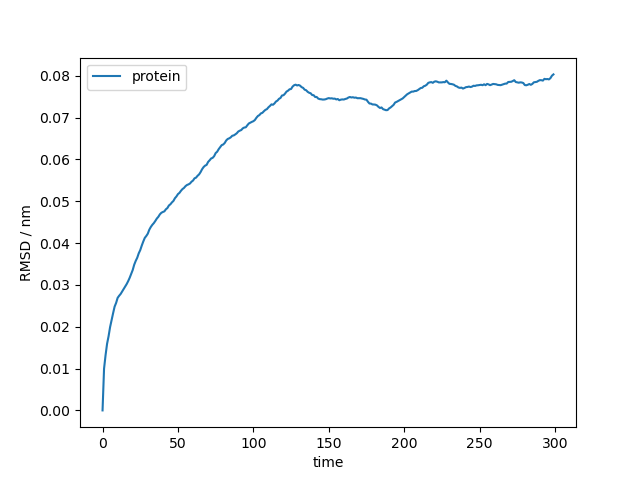

In [7]:
# make sure rmsd plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_222218'))

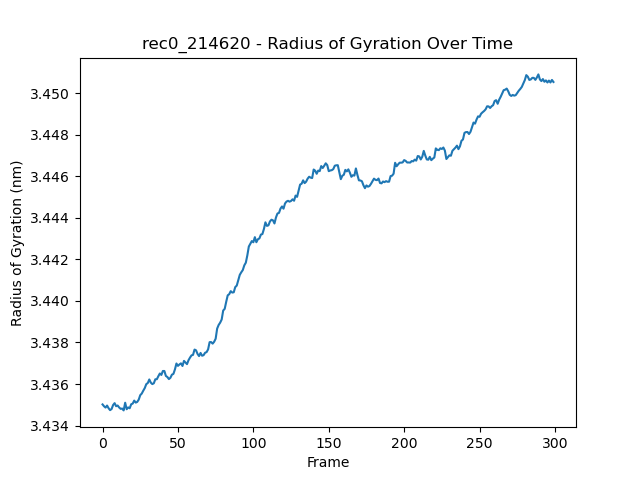

In [9]:
# make sure rgy plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_224548'))

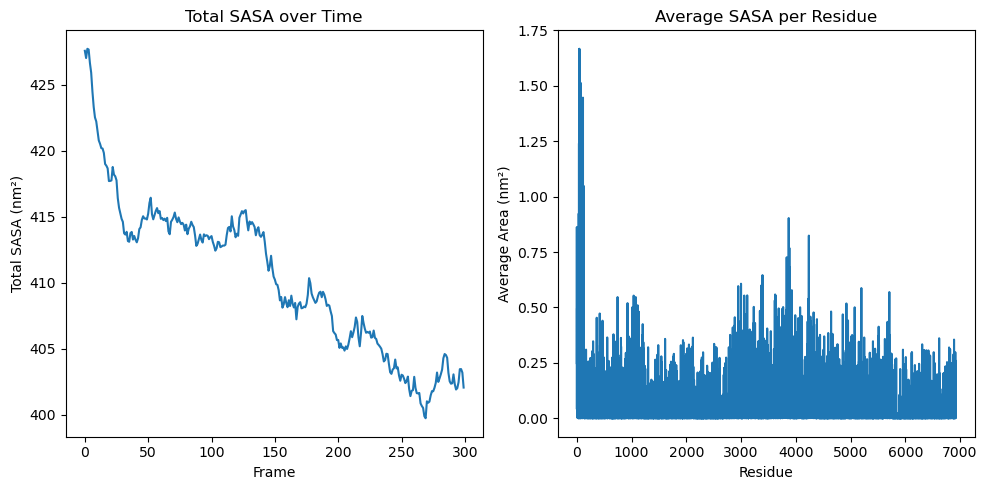

In [10]:
# make sure sasa plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_224545'))

In [11]:
# make sure trajectory and topology exist (sim2)
traj_path_2 = registry.get_mapped_path("rec0_220210")
top_path_2 = registry.get_mapped_path("top_sim0_220202")

assert os.path.exists(traj_path_2)
assert os.path.exists(top_path_2)

In [15]:
#verify the total cost
def calculate_llm_cost(input_tokens, output_tokens, model):
    pricing_2024 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 5/1e6, "output": 15/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
        "claude-3-opus": {"input": 15/1e6, "output": 75/1e6},
        "claude-3.5-sonnet": {"input": 3/1e6, "output": 15/1e6},
    }
    pricing_2025 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 2.5/1e6, "output": 10/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
    }
    
    prices = pricing_2025[model]
    cost = (input_tokens * prices["input"]) + (output_tokens * prices["output"])
    return round(cost, 6)

llm_cost = calculate_llm_cost(cb.prompt_tokens, cb.completion_tokens, agent.llm.model_name)
print('Input tokens:',cb.prompt_tokens)
print('Output tokens:',cb.completion_tokens)
print('LLM costs: $',llm_cost)

Input tokens: 100684
Output tokens: 1991
LLM costs: $ 0.27162
